In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from skimage import measure
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [3]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-10_10-48-51\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageSummary-260422-135733.mat"
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Figures\OPhys\VIP_SD\panels"

In [4]:
vs = VoltageSummary(datapath)

In [18]:
dmd1_traces = vs.get_roi_traces(dmd=1,trial=1)
dmd2_traces = vs.get_roi_traces(dmd=2,trial=1)

In [72]:
dmd = 2
meanim = vs.get_mean_image(dmd=dmd)
dmd_masks = vs.get_roi_masks(dmd=dmd)

<IPython.core.display.Javascript object>


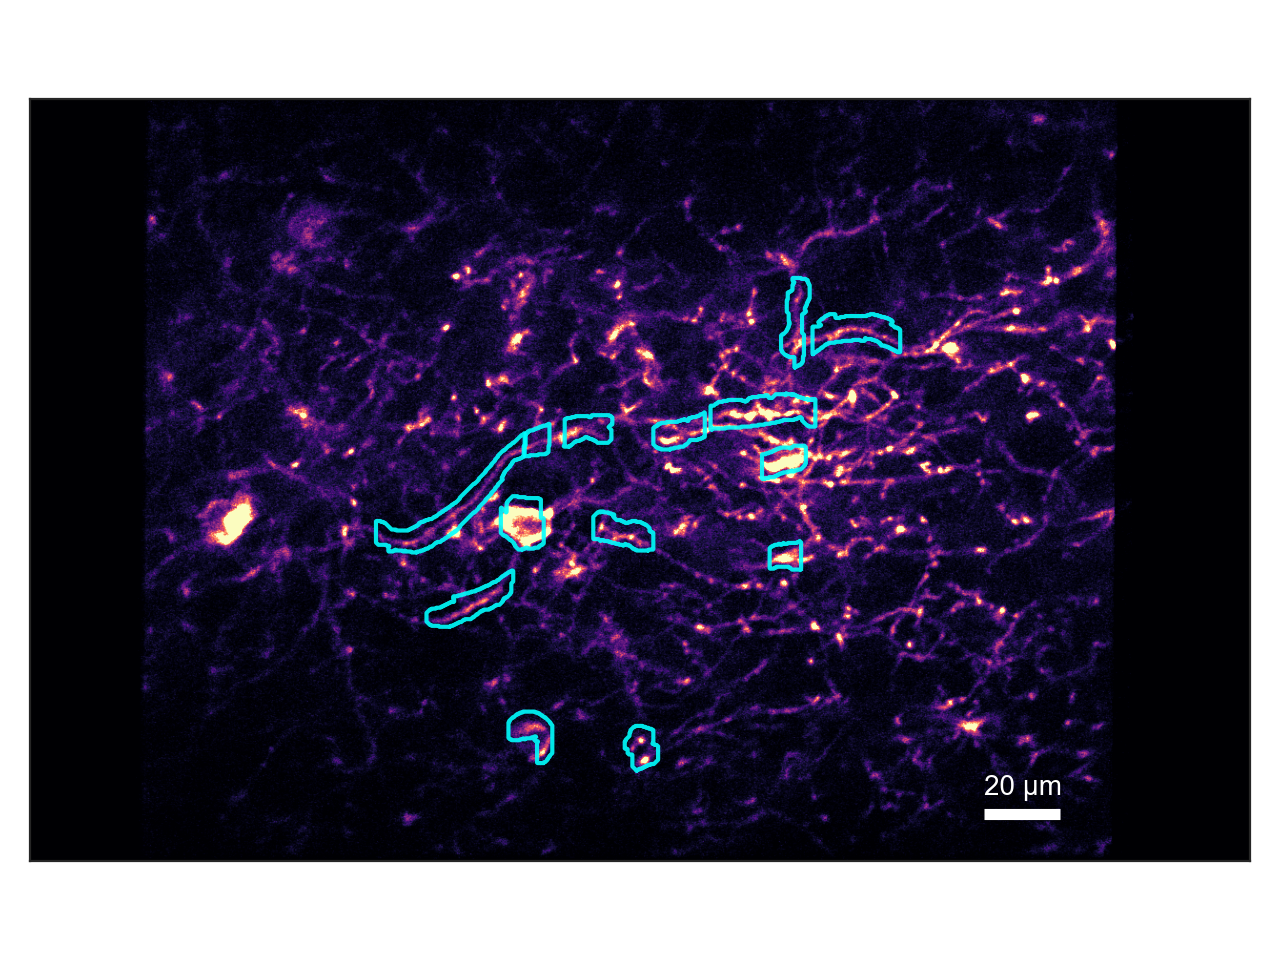

In [74]:
scale = 0.25  # um/px
fig, ax = plt.subplots()

ax.imshow(meanim, cmap="magma", vmax=200, vmin=0)

for roi_idx in range(dmd_masks.shape[-1]):
    mask = dmd_masks[:, :, roi_idx]

    # --- plot contour ---
    contours = measure.find_contours(mask.astype(float), level=0.5)
    for contour in contours:
        ax.plot(
            contour[:, 1]-10,
            contour[:, 0]-3,
            color="cyan",
            lw=1.5,
            alpha=0.9,
        )

    # --- compute centroid ---
    ys, xs = np.where(mask)
    if len(xs) == 0:
        continue

    cx = xs.mean()
    cy = ys.mean()

#     # --- add label ---
#     ax.text(
#         cx+15,
#         cy-20,
#         str(roi_idx),
#         color="cyan",
#         fontsize=12)

# scale bar
bar = 20  # um
span = bar / scale

xpos = 1000
ypos = 750

ax.plot(
    [xpos, xpos + span],
    [ypos, ypos],
    color="w",
    lw=4,
    solid_capstyle="butt",
)
ax.text(
    xpos,
    ypos - meanim.shape[0] * 0.025,
    f"{bar} μm",
    color="w",
)

ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()

filen = f'2026-04-30_VoltageImaging_DMD{dmd}_meanIM'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

In [75]:
im_rate = 10.8e3

<IPython.core.display.Javascript object>


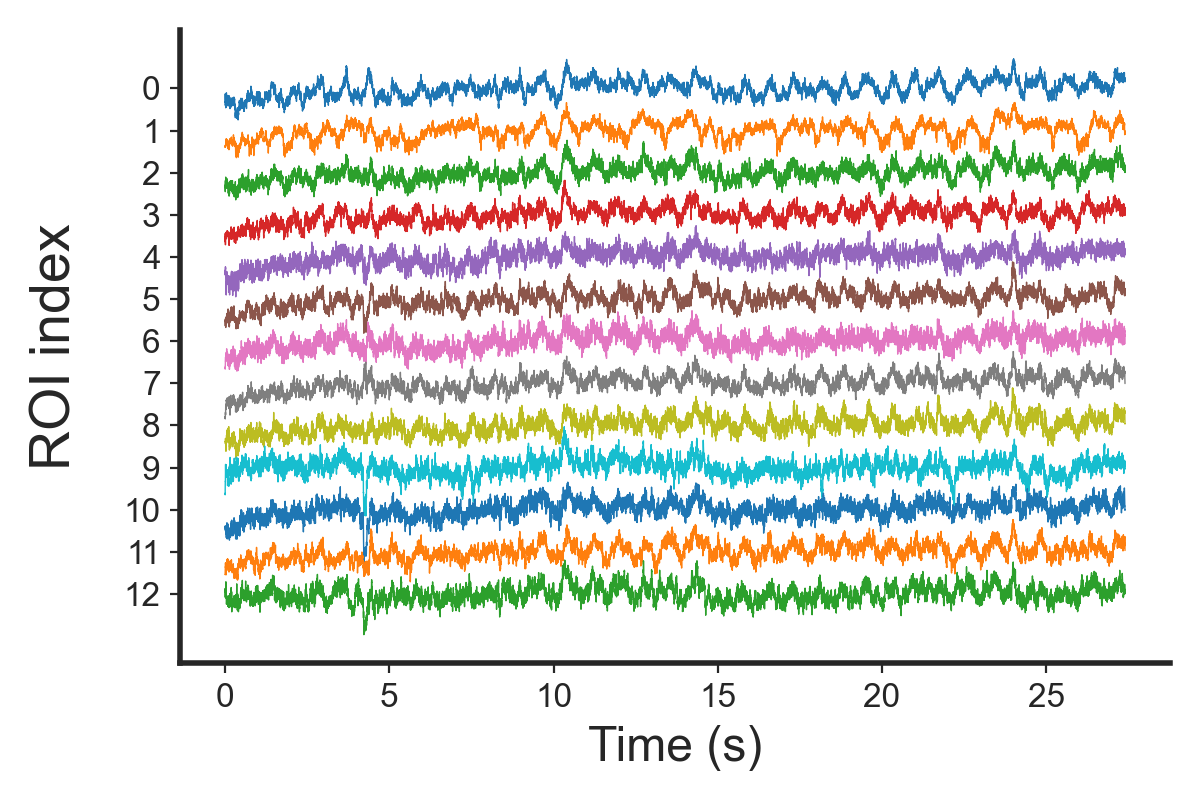

In [76]:
dmd_traces = [dmd1_traces,dmd2_traces]

plot_traces = dmd_traces[dmd-1]

stack_spacing = 5
time = np.linspace(0,plot_traces.shape[0]/im_rate,plot_traces.shape[0])
n_roi = plot_traces.shape[1]
y_offsets = -np.arange(n_roi) * stack_spacing

fig,ax=plt.subplots(figsize=(6,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

for roi in range(plot_traces.shape[1]):
    
    trace = plot_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],trace[::]-stack_spacing*roi,lw=0.5)

ax.set_yticks(y_offsets)
ax.set_yticklabels([str(r-min(range(n_roi))) for r in range(n_roi)])
ax.set_ylabel("ROI index", fontsize=20,labelpad=15)    

ax.set_xlabel('Time (s)')
    
fig.tight_layout()
filen = f'2026-04-30_VoltageTrace_DMD{dmd}'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


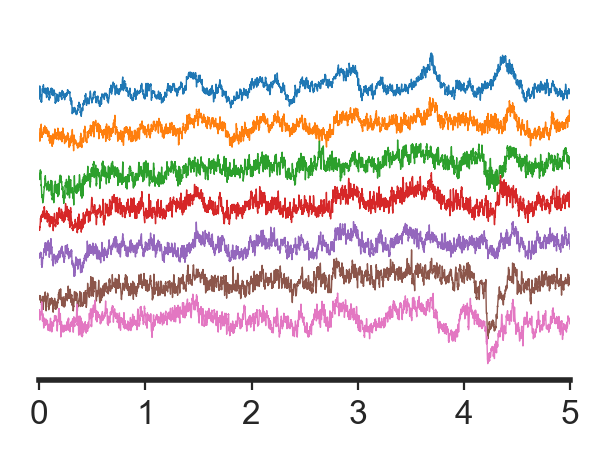

In [78]:
dmd_traces = [dmd1_traces,dmd2_traces]

plot_traces = dmd_traces[dmd-1]
skip = 2
stack_spacing = 2
time = np.linspace(0,plot_traces.shape[0]/im_rate,plot_traces.shape[0])
n_roi = plot_traces.shape[1]
y_offsets = -np.arange(n_roi)[::skip] * stack_spacing

fig,ax=plt.subplots(figsize=(3,2.3))

sns.despine(left=True)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

for roi in range(plot_traces.shape[1])[::skip]:
    
    trace = plot_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],trace[::]-stack_spacing*roi,lw=0.5)

ax.set_yticks([])

# ax.set_xlabel('Time (s)')
window = [0,5]
ax.set_xlim(window[0],window[1])
fig.tight_layout()
filen = f'2026-04-30_VoltageTrace_DMD{dmd}_sec{window[0]}-{window[1]}'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)